# ***This is the implemented Linear regression model for the Original Dataset***

Imports

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from itertools import product
import datetime
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import gaussian_kde

Loading the Dataset

In [110]:
# Load the dataset
Cars_df = pd.read_csv('Cars.csv')

Removing the Missing Values

In [111]:
# Drop rows with any missing values
data_frame = Cars_df.dropna()

Treating the outliers

In [112]:
data_frame = pd.read_csv('Cars.csv')

# Applying log transformation to the 'Price' column to reduce skewness
data_frame['Log_Price'] = np.log1p(data_frame['Price'])  # log1p is used to handle zero values in the data


filtered_file_path = 'Cars_Filtered.csv'
data_frame.to_csv(filtered_file_path, index=False)

Price Distributions before and after the log transformation

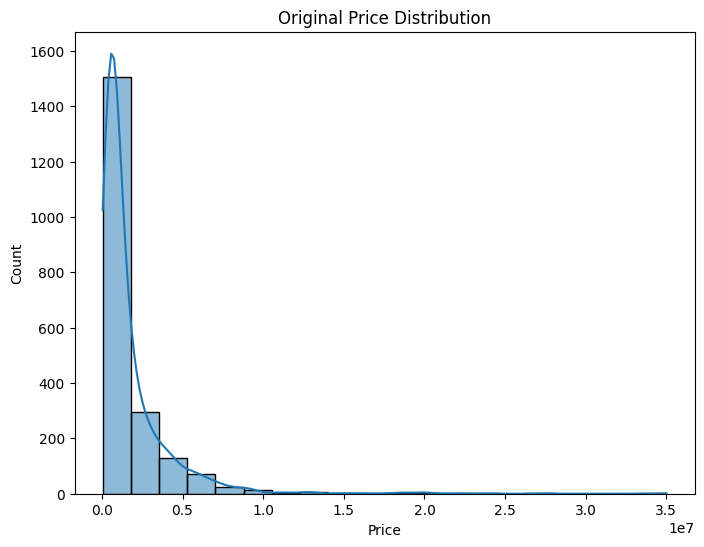

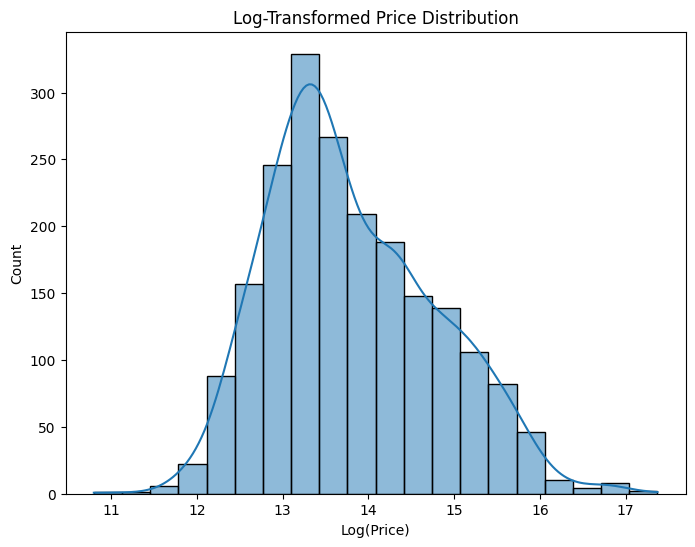

In [113]:
# Plotting the distribution of the original 'Price'
plt.figure(figsize=(8, 6))
sns.histplot(data=data_frame['Price'], bins=20, kde=True)
plt.title('Original Price Distribution')
plt.xlabel('Price')
plt.show()


# Plotting the distribution of the log-transformed 'Price'
plt.figure(figsize=(8, 6))
sns.histplot(data=data_frame['Log_Price'], bins=20, kde=True)
plt.title('Log-Transformed Price Distribution')
plt.xlabel('Log(Price)')
plt.show()

Switching the categorical cols to numerical ones ( Encoding )





In [114]:
label_encoder = LabelEncoder()

# Fit ( Adapting ) the encoder to the 'Model' column and transform it to numeric labels
data_frame['Model ID'] = label_encoder.fit_transform(data_frame['Model'])

# This is Optional: I will create a mapping of malls to their identifiers, if I need to reference them later.
Model = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

# Sorted list of car brands according to thr Indian market
sorted_brands = [
    "Maruti Suzuki", "Hyundai", "Tata", "Mahindra", "Toyota", "Honda",
    "Kia", "Renault", "Ford", "Volkswagen", "Nissan",
    "Skoda", "MG", "Jeep", "Mercedes-Benz", "BMW", "Audi", "Volvo", "Land Rover", "Lexus",
    "Porsche", "Ferrari", "Maserati", "Rolls-Royce",
    "Chevrolet", "Fiat", "Mitsubishi", "Datsun", "Isuzu", "Ssangyong"
]

# Create a custom mapping from the sorted list ( it is optional , just for me to know the sorting...)
brand_mapping = {brand: index for index, brand in enumerate(sorted_brands)}

# Apply the custom mapping to the DataFrame
data_frame['Brand ID'] = data_frame['Make'].map(brand_mapping)

data_frame['Fuel ID'] = label_encoder.fit_transform(data_frame['Fuel Type'])
Fuel = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

data_frame['Transmission ID'] = label_encoder.fit_transform(data_frame['Transmission'])
Transmission = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

data_frame['Location ID'] = label_encoder.fit_transform(data_frame['Location'])
Location = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

data_frame['Color ID'] = label_encoder.fit_transform(data_frame['Color'])
Color = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

data_frame['Owner ID'] = label_encoder.fit_transform(data_frame['Owner'])
Owner = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

data_frame['Seller ID'] = label_encoder.fit_transform(data_frame['Seller Type'])
Seller = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

data_frame['Drivetrain ID'] = label_encoder.fit_transform(data_frame['Drivetrain'])
Drivetrain = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

data_frame.to_csv('Cars_Encoded.csv', index=False)

Exctracting numerical values from string features

In [115]:

# The regex pattern '\d+' matches one or more digits
data_frame['Engine Size'] = data_frame['Engine'].str.extract('(\d+)')
# Convert the column to a numeric type
data_frame['Engine Size'] = pd.to_numeric(data_frame['Engine Size'], errors='coerce')


data_frame['Power'] = data_frame['Max Power'].str.replace(r' bhp @ \d+ rpm', '', regex=True)
# Convert the column to a numeric type
data_frame['Power'] = pd.to_numeric(data_frame['Power'], errors='coerce')


data_frame['Torque'] = data_frame['Max Torque'].str.replace(r' Nm @ \d+ rpm', '', regex=True)
# Convert the column to a numeric type
data_frame['Torque'] = pd.to_numeric(data_frame['Torque'], errors='coerce')

Dropping the categorical columns

In [116]:
# Identify columns that have data type 'object' (text)
text_columns = data_frame.select_dtypes(include=['object']).columns
# Drop the identified text columns
data_frame = data_frame.drop(text_columns, axis=1)
data_frame = data_frame.dropna()


*   Changing the name of the target from ( Log_Price ) to ( Aim_Price )
*   Dropping the Log_Price Columns
*   Adding the Aim_Price Column and Making it as the last column in the table

In [117]:
Aim_Price = data_frame["Log_Price"]
data_frame = data_frame.drop(["Log_Price"],axis=1)
data_frame["Aim_Price"]= Aim_Price
data_frame.to_csv("Cars_Final.csv")

In [118]:
data_frame.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Model ID,Brand ID,...,Transmission ID,Location ID,Color ID,Owner ID,Seller ID,Drivetrain ID,Engine Size,Power,Torque,Aim_Price
count,1.785000e+03,1785.000000,1.785000e+03,1785.000000,1785.000000,1785.000000,1785.000000,1785.000000,1785.000000,1785.000000,...,1785.000000,1785.000000,1785.000000,1785.000000,1785.000000,1785.000000,1785.000000,1785.000000,1785.000000,1785.000000
mean,1.737956e+06,2016.969188,5.213507e+04,4279.953501,1768.318768,1591.470028,5.304762,52.092045,520.935014,6.202801,...,0.556863,31.830812,10.515966,1.390476,1.965826,1.024650,1672.971989,128.498431,243.354716,13.857954
std,2.458610e+06,2.875334,5.953905e+04,431.223803,130.325940,134.191844,0.812669,14.961527,300.418291,6.504249,...,0.496895,19.352653,5.355092,0.857190,0.196544,0.543467,628.934049,63.583852,137.346820,0.935563
min,1.410000e+05,1988.000000,1.000000e+00,3395.000000,1475.000000,1213.000000,2.000000,27.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,793.000000,39.000000,54.000000,11.856522
25%,5.250000e+05,2015.000000,2.800000e+04,3987.000000,1695.000000,1485.000000,5.000000,42.000000,271.000000,1.000000,...,0.000000,15.000000,7.000000,1.000000,2.000000,1.000000,1197.000000,83.000000,115.000000,13.171155
50%,8.500000e+05,2017.000000,4.800000e+04,4355.000000,1775.000000,1545.000000,5.000000,50.000000,506.000000,4.000000,...,1.000000,32.000000,14.000000,1.000000,2.000000,1.000000,1497.000000,115.000000,200.000000,13.652993
75%,1.889999e+06,2019.000000,7.000000e+04,4620.000000,1831.000000,1672.000000,5.000000,60.000000,802.000000,13.000000,...,1.000000,45.000000,15.000000,1.000000,2.000000,1.000000,1995.000000,169.000000,350.000000,14.452087
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000,1049.000000,29.000000,...,1.000000,76.000000,16.000000,5.000000,2.000000,3.000000,6592.000000,660.000000,780.000000,17.370859


In [119]:
data_frame.corr()["Aim_Price"]

Price                 0.808469
Year                  0.454633
Kilometer            -0.141025
Length                0.794539
Width                 0.785620
Height                0.208578
Seating Capacity      0.112376
Fuel Tank Capacity    0.755886
Model ID             -0.128389
Brand ID              0.639945
Fuel ID              -0.255201
Transmission ID      -0.663450
Location ID          -0.132880
Color ID             -0.160770
Owner ID              0.011584
Seller ID            -0.082494
Drivetrain ID        -0.065834
Engine Size           0.726533
Power                 0.842549
Torque                0.827212
Aim_Price             1.000000
Name: Aim_Price, dtype: float64

Making the correct data frame

In [120]:
data_frame = data_frame[['Year','Seating Capacity', 'Transmission ID','Power','Aim_Price']]

Checking the correlation between the predictors and the target

In [121]:
data_frame.corr()["Aim_Price"]

Year                0.454633
Seating Capacity    0.112376
Transmission ID    -0.663450
Power               0.842549
Aim_Price           1.000000
Name: Aim_Price, dtype: float64

Checking the correlation between the predictors

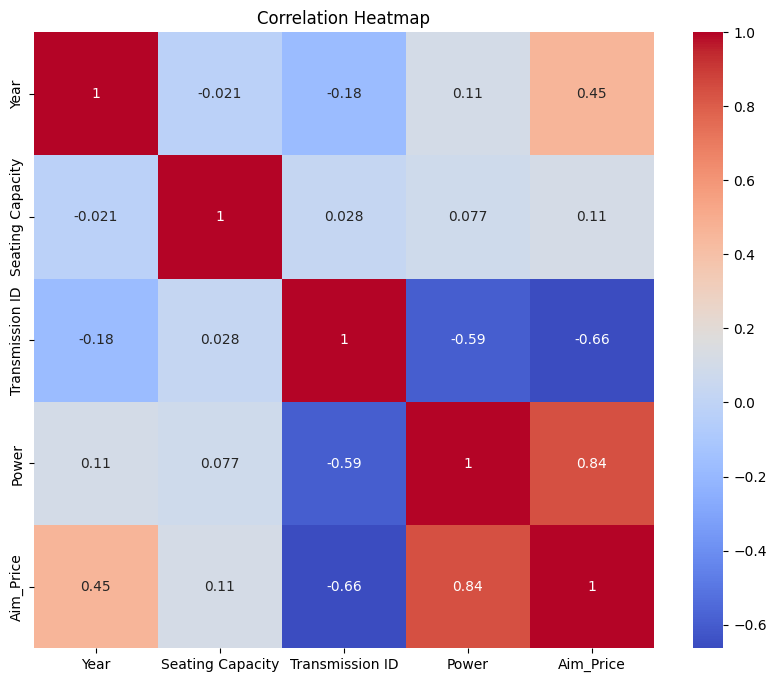

In [122]:
# Correlation Analysis
correlation_matrix = data_frame.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Declaring the Predictors

In [123]:
x = data_frame[['Year','Seating Capacity', 'Transmission ID','Power']]

Declaring the target

In [124]:
y = data_frame['Aim_Price']

Splitting the dataset 70-30

In [125]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3)

Declaring the model

In [126]:
model = LinearRegression()

Fitting the model. Start training

In [127]:
model.fit(x_train, y_train)

LinearRegression()

Checking the coefficients that makes the best line for this dataset

In [128]:
pd.DataFrame(model.coef_, x.columns, columns = ['Coeff'])

,Coeff
Year,0.120658
Seating Capacity,0.092434
Transmission ID,-0.373837
Power,0.009845


Testing the model

In [129]:
predictions = model.predict(x_test)

Evaluating the model

In [130]:
print("MAE : " , metrics.mean_absolute_error(y_test, predictions))

MAE :  0.24435687635153963


In [131]:
print("MSE : " , metrics.mean_squared_error(y_test, predictions))

MSE :  0.11260538164789491


In [132]:
print("RMSE : ",np.sqrt(metrics.mean_squared_error(y_test, predictions)))

RMSE :  0.33556725353927924


The Accuracy :

In [133]:
r2_score = model.score(x_test,y_test)
print(r2_score*100,'%')
print(r2_score)

87.20858264486257 %
0.8720858264486258


Visual Data for more information

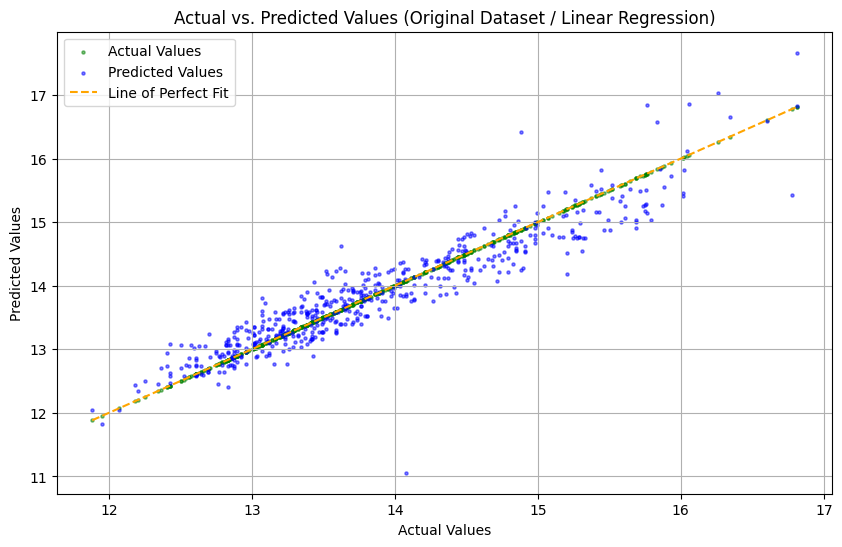

In [134]:
plt.figure(figsize=(10, 6))

# Plot the actual values in green
plt.scatter(y_test, y_test, color='green', s=5, alpha=0.5, label='Actual Values')

# Plot the predicted values in blue
plt.scatter(y_test, predictions, color='blue', s=5, alpha=0.5, label='Predicted Values')  # Same size reduction as actual

# Add an orange line for perfect predictions
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='orange', linestyle='--', label='Line of Perfect Fit')

plt.title('Actual vs. Predicted Values (Original Dataset / Linear Regression)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.legend()
plt.show()

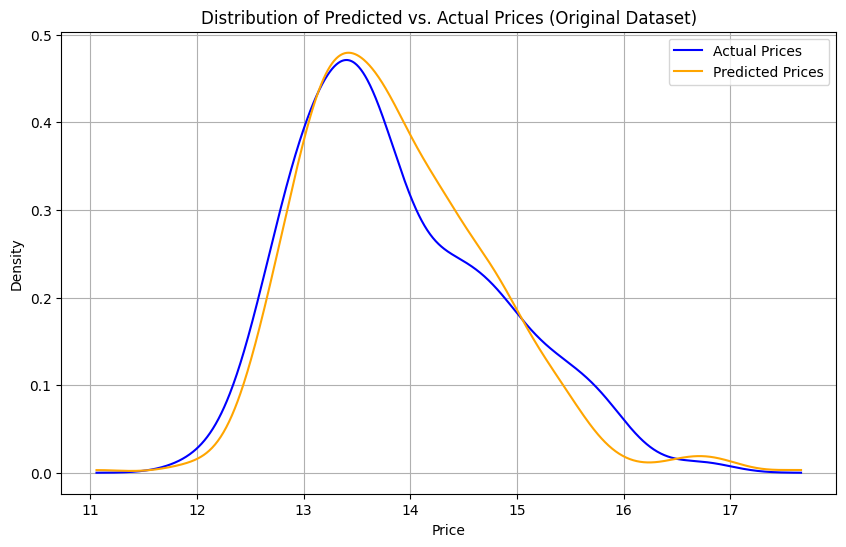

In [135]:
plt.figure(figsize=(10, 6))

# Calculate the density using Gaussian Kernel Density Estimation
density_actual = gaussian_kde(y_test)
density_pred = gaussian_kde(predictions)

# Set up a range of values for x
x_vals = np.linspace(min(min(y_test), min(predictions)), max(max(y_test), max(predictions)), 1000)

# Calculate the density values for each range
y_actual = density_actual(x_vals)
y_pred = density_pred(x_vals)

# Plotting the density estimates as lines
plt.plot(x_vals, y_actual, label='Actual Prices', color='blue')
plt.plot(x_vals, y_pred, label='Predicted Prices', color='orange')

# Adding titles and labels
plt.title('Distribution of Predicted vs. Actual Prices (Original Dataset)')
plt.xlabel('Price')
plt.ylabel('Density')
plt.grid(True)
plt.legend()

# Show the plot
plt.show()